# GG-PI: Training Example for Para-H₂

This notebook demonstrates how to collect training data and train the GG-PI model for para-hydrogen using a custom simulator.

## Overview

For the target system (T=25K, P=32 PIMD), we sample from the following conditional distribution:

$$
\rho_\tau (x|y) \propto \exp\left(-\beta_P \left(\frac{1}{2}m \omega_e^2 (x-y)^2 + V_{\text{SG}}(x)\right)\right)
$$

where:
- $V_{\text{SG}}(x)$ is the Silvera-Goldman potential
- $m$ is the mass of para-hydrogen
- $T_P = T \times P = 800K$
- $\beta_P = 1/(k_B T_P)$
- $\omega_e = \sqrt{2}k_B T_P / \hbar$

All units are in atomic units.

**Training Setup:**
- System: 64 molecules in a cubic box(same density)
- Box length: 28.1337 Bohr
- Cutoff: 14 Bohr
- Training pairs: 20,000 $(x, y)$ samples

⏱️ Expected runtime: ~10 minutes for data collection

In [1]:
# =============================================================================
# Import Dependencies
# =============================================================================
from pathlib import Path
import torch
import numpy as np
import matplotlib.pyplot as plt
import pickle
import time

# GG-PI package imports
from ggpi.simulation import SilveraGoldmanPotential, LangevinIntegrator, MDConfig, calculate_omega
from ggpi.nn import ViSNet_Velocity_Network
from ggpi.sampling import ConditionalFlowSampler, ConditionalLinearFlowMatching, GibbsSampler
from ggpi.utils import MolecularDataset

# Set paths
cwd = Path.cwd()
data_dir = cwd.parent / "data"
checkpoint_dir = cwd.parent / "checkpoints"

# Set random seeds for reproducibility
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Data directory: {data_dir}")

Using device: cuda
Data directory: /home/weizhouwang/projects/gg-pi-released/data


## Step 1: MD Simulation

Using Bayes' theorem, we collect classical MD trajectories at $T_P = 800K$ to build training data.
Higher temperature alleviates sampling difficulty.

⏱️ Expected runtime: ~5-10 minutes

In [2]:
# =============================================================================
# Simulation Parameters
# =============================================================================
T_ref = 25          # Reference temperature (Kelvin)
P = 32              # Number of beads
TP = T_ref * P      # Effective temperature for sampling

L = 28.1337         # Box length (Bohr)
cutoff = 14         # Cutoff distance (Bohr)
cell = np.array([[L, 0, 0], [0, L, 0], [0, 0, L]])
box = np.array([L, L, L])

MASS = 3674.7       # Para-H2 mass (electron masses)

# Initialize potential and integrator
sg_pot = SilveraGoldmanPotential(cutoff=cutoff, cell=cell, num_cpus=8)

md_config = MDConfig(
    temperature=TP,
    friction=0.01,
    dt=0.5,        
    mass=MASS
)
integrator = LangevinIntegrator(sg_pot, md_config)

# Simulation parameters
ntrajs = 20
nsteps = 550_000
sample_interval = 500

# Initialize positions on cubic lattice
positions, velocities = integrator.initialize_cubic_lattice(
    box_size=box,
    spacing=6.0,
    ntrajs=ntrajs,
    random_displacement=1.0
)
natoms = positions.shape[1]
print(f"System: {ntrajs} trajectories, {natoms} atoms each")

Integrator initialized:
  dt: 0.5 fs -> 20.670500 a.u.
  gamma: 0.01 fs^-1 -> 0.000242 a.u.
  T: 800 K -> 2.533440e-03 a.u.
  mass: 3674.7 m_e
System: 20 trajectories, 64 atoms each


In [3]:
# =============================================================================
# Run MD Simulation
# =============================================================================
start = time.time()

trajectory, energies, temperatures, kinetic = integrator.run(
    nsteps=nsteps,
    sample_interval=sample_interval,
)

# Remove burn-in period
nsteps_burn_in = 100
trajectory = trajectory[:, nsteps_burn_in:, :, :]

print(f"MD trajectory shape: {trajectory.shape}")
print(f"Energies shape: {energies.shape}")
print(f"Simulation time: {time.time() - start:.1f} seconds")

MD simulation:   0%|          | 0/550000 [00:00<?, ?it/s]

MD simulation: 100%|██████████| 550000/550000 [07:11<00:00, 1275.53it/s] 

MD trajectory shape: (20, 1000, 64, 3)
Energies shape: (20, 1100)
Simulation time: 431.2 seconds


## Step 2: Build Training Data

After collecting MD trajectories, we sample conditions from the theoretical Gaussian distribution:

$$
\sigma_{\text{theory}} = \sqrt{\frac{1}{\beta_P m \omega_e^2}} = \sqrt{\frac{k_B T_P}{m \omega_e^2}}
$$

using Bayes' theorem.


In [4]:
# =============================================================================
# Build Conditional Kernel
# =============================================================================
AU_TIME_PER_FS = 41.341
KB_AU = 3.1668114e-6  # Hartree/Kelvin

omega_fs = calculate_omega(TP)
omega_au = omega_fs / AU_TIME_PER_FS  # Convert fs^-1 to au^-1
kT_au = TP * KB_AU  # Convert Kelvin to atomic units

sigma_theoretical = np.sqrt(kT_au / (MASS * omega_au**2))
print(f"Theoretical sigma: {sigma_theoretical:.6f} au")

# Build training pairs (x_target, x_cond) using Bayes' theorem
x_target = trajectory.reshape(-1, trajectory.shape[-2], trajectory.shape[-1])
x_cond = x_target + sigma_theoretical * np.random.normal(size=x_target.shape)

print(f"Target shape: {x_target.shape}")
print(f"Condition shape: {x_cond.shape}")

Theoretical sigma: 0.231747 au
Target shape: (20000, 64, 3)
Condition shape: (20000, 64, 3)


## Step 3: Train the Model

In [5]:
# =============================================================================
# Prepare Dataset
# =============================================================================
NUM_ATOMS_TRAIN = x_target.shape[1]
dataset = MolecularDataset(x_target, x_cond, torch.tensor([1] * NUM_ATOMS_TRAIN))

prior_sigma = torch.tensor(
    [sigma_theoretical] * NUM_ATOMS_TRAIN,
    dtype=torch.float32, device=device
).unsqueeze(0).unsqueeze(-1)

BOX_TRAIN = torch.tensor(box, dtype=torch.float32, device=device)

print(f"Prior sigma shape: {prior_sigma.shape}")
print(f"Dataset size: {len(dataset)}")

Prior sigma shape: torch.Size([1, 64, 1])
Dataset size: 20000


In [6]:
# =============================================================================
# Build and Train Model
# =============================================================================
from torch.utils.data import DataLoader
from tqdm import tqdm

torch.cuda.empty_cache()

# Model configuration
batch_size = 256
num_epochs = 10

model = ViSNet_Velocity_Network(
    n_layers=2,
    hidden_channels=24,
    time_embedding_dim=24,
    num_heads=4,
    equivariance_feats_dim=3,
    pos_dim=3,
    cutoff=8,
    encode_rela_dis=True
).to(device)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {num_params:,}")

# Setup trainer
trainer = ConditionalLinearFlowMatching(
    model, prior_sigma=prior_sigma, box_size=BOX_TRAIN
).to(device)

# Setup optimizer and scheduler
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
optimizer = torch.optim.AdamW(trainer.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=num_epochs, eta_min=1e-6
)

# Training loop
trainer.train()
records = []

for epoch in range(num_epochs):
    epoch_loss = 0.0
    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}")
    
    for batch in pbar:
        optimizer.zero_grad()
        
        x_target_batch, _, Z_sys_batch = batch
        x_target_batch = x_target_batch.to(device)
        x_cond_batch = x_target_batch + sigma_theoretical * torch.randn_like(x_target_batch)
        Z_sys_batch = Z_sys_batch.to(device)
        
        loss = trainer(x_target_batch, x_cond_batch, Z_sys_batch)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        epoch_loss += loss.item()
        pbar.set_postfix({'Loss': f'{loss.item():.4f}', 'LR': f'{optimizer.param_groups[0]["lr"]:.2e}'})
    
    records.append(epoch_loss)
    scheduler.step()
    print(f"Epoch {epoch+1}/{num_epochs}, Avg Loss: {epoch_loss/len(dataloader):.4f}")

Model parameters: 35,016
Extra noise sigma: 0


Epoch 1/10: 100%|██████████| 79/79 [00:06<00:00, 12.19it/s, Loss=0.0849, LR=1.00e-03]


Epoch 1/10, Avg Loss: 0.0986


Epoch 2/10: 100%|██████████| 79/79 [00:08<00:00,  8.95it/s, Loss=0.0846, LR=9.76e-04]


Epoch 2/10, Avg Loss: 0.0844


...

Epoch 8/10, Avg Loss: 0.0835


Epoch 9/10: 100%|██████████| 79/79 [00:08<00:00,  9.31it/s, Loss=0.0781, LR=9.64e-05]


Epoch 9/10, Avg Loss: 0.0833


Epoch 10/10: 100%|██████████| 79/79 [00:08<00:00,  9.20it/s, Loss=0.0844, LR=2.54e-05]

Epoch 10/10, Avg Loss: 0.0835


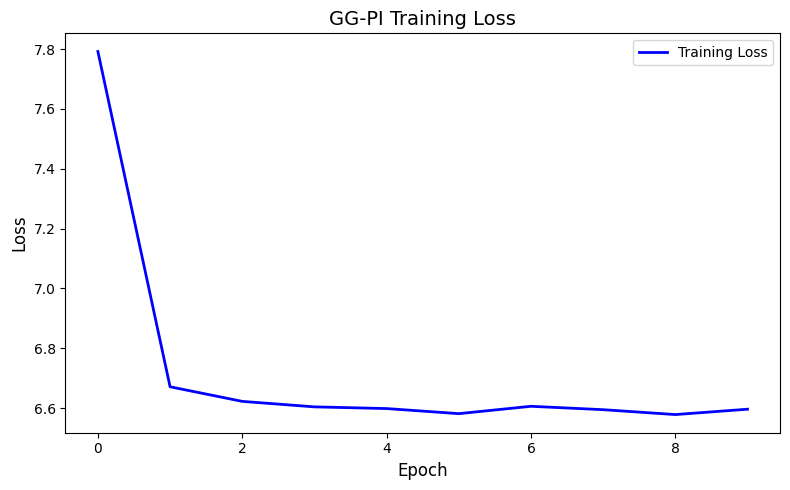

In [7]:
# =============================================================================
# Plot Training Loss
# =============================================================================
plt.figure(figsize=(8, 5))
plt.plot(records, 'b-', linewidth=2, label='Training Loss')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('GG-PI Training Loss', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

## Step 4: Validation

Validate the trained model using 172 molecules with the same density.
We compare the radial distribution function (RDF) from GG-PI with reference PIMD data.

In [8]:
# =============================================================================
# RDF Calculation Helper
# =============================================================================
import freud

def calculate_rdf(pos, box_size=None, r_range=(0.0, 14.0), nbins=50, stride=1):
    """
    Calculate radial distribution function using freud.
    
    Args:
        pos: Position array of shape (frames, atoms, 3) or (frames, beads, atoms, 3)
        box_size: Box dimensions [Lx, Ly, Lz]
        r_range: Range for RDF calculation
        nbins: Number of bins
        stride: Frame stride for efficiency
    
    Returns:
        Array of shape (nbins, 2) with [r, g(r)]
    """
    if pos.ndim == 4:
        pos = pos.reshape(-1, pos.shape[-2], pos.shape[-1])
    pos = np.asarray(pos, dtype=np.float32)[::stride]
    
    print(f"Calculating RDF for {pos.shape[0]} frames with {pos.shape[1]} atoms")
    
    if box_size is not None:
        box_size = np.asarray(box_size, dtype=np.float32)
        pos = pos - np.floor(pos / box_size) * box_size
    
    box = freud.box.Box(Lx=box_size[0], Ly=box_size[1], Lz=box_size[2])
    rdf = freud.density.RDF(bins=nbins, r_max=r_range[1], r_min=r_range[0])
    
    for i in range(pos.shape[0]):
        rdf.compute(system=(box, pos[i]), reset=False)
    
    return np.column_stack((rdf.bin_centers, rdf.rdf))

MD data shape: (1001, 172, 3)
Box size: [39.115 39.115 39.115]
Temperature: 100K
PIMD data shape: (100, 32, 172, 3)
Calculating RDF for 1001 frames with 172 atoms
Calculating RDF for 3200 frames with 172 atoms


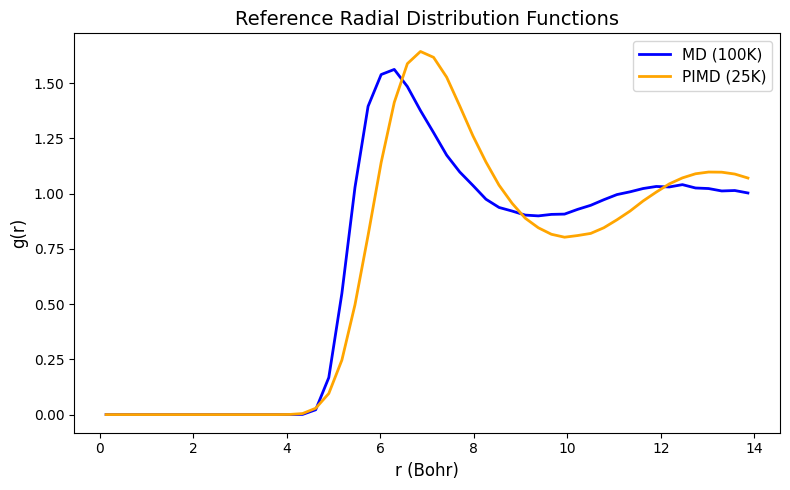

In [9]:
# =============================================================================
# Load Reference Data
# =============================================================================
# Load MD reference data
data_path = data_dir / "parah2_md_100K.pkl"
with open(data_path, "rb") as f:
    data = pickle.load(f)

pos = np.array(data["x"])
box_size = np.array(data["box_size"])
Z = np.array(data["Z"])
prior_sigma_val = np.array([sigma_theoretical] * pos.shape[1])

print(f"MD data shape: {pos.shape}")
print(f"Box size: {box_size}")
print(f"Temperature: {data['T']}K")

# Load PIMD reference data
pimd_path = data_dir / "parah2_pimd_25KP32.pkl"
with open(pimd_path, "rb") as f:
    pimd_data = np.array(pickle.load(f)['x'])
print(f"PIMD data shape: {pimd_data.shape}")

# Calculate reference RDFs
rdf_md = calculate_rdf(pos, box_size=box_size)
rdf_pimd = calculate_rdf(pimd_data, box_size=box_size)

# Plot reference comparison
plt.figure(figsize=(8, 5))
plt.plot(rdf_md[:, 0], rdf_md[:, 1], 'b-', linewidth=2, label='MD (100K)')
plt.plot(rdf_pimd[:, 0], rdf_pimd[:, 1], 'orange', linewidth=2, label='PIMD (25K)')
plt.xlabel('r (Bohr)', fontsize=12)
plt.ylabel('g(r)', fontsize=12)
plt.title('Reference Radial Distribution Functions', fontsize=14)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [10]:
# =============================================================================
# Setup Sampler with Trained Model
# =============================================================================
model = torch.compile(model)  # PyTorch >= 2.0 optimization

sampler = ConditionalFlowSampler(
    model,
    Z=torch.as_tensor(Z, dtype=torch.int64, device=device),
    prior_sigma=torch.as_tensor(prior_sigma_val, dtype=torch.float32, device=device),
    box_size=torch.as_tensor(box_size, dtype=torch.float32, device=device),
    device=device,
    sample_method='heun',
    fix_graph=True,
    num_steps=5,
    max_batch_size=2048,
    return_cpu=False
)

gibbs = GibbsSampler(
    sampler,
    box_size=torch.as_tensor(box_size, dtype=torch.float32, device=device),
    device=device,
    cutoff=8
)

ConditionalFlowSampler initialized: method=heun, steps=5, fix_graph=True
GibbsSampler initialized on cuda, cutoff=8.0, cache_interval=5, cache_threshold=2.0, use_cache=True


In [11]:
# =============================================================================
# Run GG-PI Sampling
# =============================================================================
torch.cuda.empty_cache()

# Select random initial configurations
num_initial = 20
random_indices = np.random.choice(pos.shape[0], num_initial, replace=False)
initial_configs = pos[random_indices]
initial_configs = torch.as_tensor(initial_configs, dtype=torch.float32, device=device)

print(f"Initial configurations: {initial_configs.shape}")

# Run Gibbs sampling
start = time.time()
output, history = gibbs.sample(
    initial_configs,
    num_beads=32,
    max_iterations=800,
    record_freq=100
)
print(f"Gibbs sampling completed in {time.time() - start:.2f} seconds")

Initial configurations: torch.Size([20, 172, 3])
Initial Rg: 4.5178824570335507e-10, num_beads: 32
Step: 100/800, Rg: 0.7215884327888489
Step: 200/800, Rg: 0.7305544018745422
Step: 300/800, Rg: 0.7396970391273499
Step: 400/800, Rg: 0.7396490573883057
Step: 500/800, Rg: 0.7320752739906311
Step: 600/800, Rg: 0.739363431930542
Step: 700/800, Rg: 0.7400534152984619
Step: 800/800, Rg: 0.7435458302497864
Gibbs sampling completed in 81.33 seconds


Calculating RDF for 640 frames with 172 atoms
Calculating RDF for 20 frames with 172 atoms


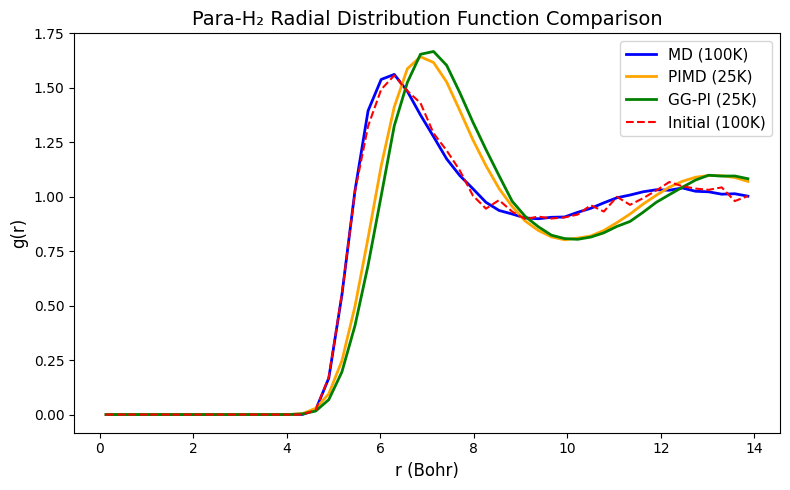

In [12]:
# =============================================================================
# Final Comparison
# =============================================================================
rdf_ggpi = calculate_rdf(output, box_size=box_size)
rdf_init = calculate_rdf(initial_configs.cpu().numpy(), box_size=box_size)

plt.figure(figsize=(8, 5))
plt.plot(rdf_md[:, 0], rdf_md[:, 1], 'b-', linewidth=2, label='MD (100K)')
plt.plot(rdf_pimd[:, 0], rdf_pimd[:, 1], 'orange', linewidth=2, label='PIMD (25K)')
plt.plot(rdf_ggpi[:, 0], rdf_ggpi[:, 1], 'g-', linewidth=2, label='GG-PI (25K)')
plt.plot(rdf_init[:, 0], rdf_init[:, 1], 'r--', linewidth=1.5, label='Initial (100K)')

plt.xlabel('r (Bohr)', fontsize=12)
plt.ylabel('g(r)', fontsize=12)
plt.title('Para-H₂ Radial Distribution Function Comparison', fontsize=14)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()